# Systematic Option Strategies on Crypto — and the Anatomy of a Null Result
### Replicating Lucic & Sepp (2024) on ETH/BTC Deribit data, and diagnosing why nothing worked

**Natixis CIB — Quant Analyst Internship**

---

This notebook is the companion to `project_outline.ipynb`. That one documents the
**surface-fitting library** — cleaning Deribit quotes, calibrating SVI/SSVI/eSSVI/SABR,
checking static arbitrage, serving a live screen. This one documents the **research
programme built on top of it**: a full systematic option-strategy backtest, and the
measurement work that came out of it returning nothing.

The honest summary in one line: **26 systematic strategies, no positive Sharpe, one real
effect found, and a catalogue of well-measured zeros.** That is a result, and this
notebook is written to make the zeros as legible as the positive.

By the end you will be able to:

1. Run the systematic roll backtester and read its paper-style results table.
2. Explain why a coin-settled inverse option needs a **premium-adjusted delta**, and see
   how wrong the plain Black delta is.
3. See why delta-hedging leaves a **residual directional beta**, and trace it to vanna.
4. Read the volatility risk premium on ETH and see why it is not tradeable.
5. Recognise the two parameter traps that cost the most time on this project.
6. Audit a research pipeline for look-ahead, and find the contaminated input we had.
7. Calibrate an estimator by Monte Carlo *before* interpreting it — the step that changed
   the conclusion.
8. State ETH's leverage effect with a defensible number and an honest confidence interval.

> **Runtime note.** Around **90 seconds** end to end; the Monte Carlo in §7 is the slowest
> cell (~20 s). Sections marked **[archive]** need the full options archive
> (`clean_chunks_full`, `eth_hourly_2024.parquet`), which lives on the desk machine, not
> here. Those report recorded results; everything else recomputes live.

## Table of contents

0. [Environment setup](#sec0)
1. [The programme](#sec1)
2. [The systematic strategy engine](#sec2)
3. [Strategy results, and the diagnosis](#sec3)
4. [Realised volatility: four estimators and the discretisation loss](#sec4)
5. [The spot–vol correlation: two parameter traps](#sec5)
6. [Data audit, and one contaminated input](#sec6)
7. [Monte Carlo: what the pipeline can actually see](#sec7)
8. [The leverage effect, properly measured](#sec8)
9. [The volatility risk premium: nothing to harvest](#sec9)
10. [Trials & errors](#sec10)
11. [Conclusion: a catalogue of well-measured zeros](#sec11)

<a id="sec0"></a>
## 0. Environment setup

In [1]:
import sys, warnings, inspect
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)
plt.rcParams.update({"figure.facecolor": "white", "axes.grid": True,
                     "grid.alpha": 0.3, "figure.dpi": 110})

here = Path.cwd()
PROJECT_ROOT = next((p for p in [here, *here.parents] if (p / "2 - Data").exists()), here)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print("Project root:", PROJECT_ROOT)

PERP    = str(PROJECT_ROOT / "2 - Data" / "parquets" / "eth_perp_1min_2024_2026.parquet")
RESULTS = PROJECT_ROOT / "results"
CHUNKS  = PROJECT_ROOT / "volatility_surface" / "notebooks" / "clean_chunks_full"
print("perp exists          :", Path(PERP).exists())
print("options archive here :", CHUNKS.exists(), " <- [archive] sections depend on this")

Project root: /Users/macbookair/Internship Natixis
perp exists          : True
options archive here : False  <- [archive] sections depend on this


In [2]:
from volatility_surface.backtest import roll_engine as R
from volatility_surface.backtest import roll_results as RR
from volatility_surface.backtest import leverage as LEV
from volatility_surface.backtest import spot_vol_corr as SV
from volatility_surface.backtest import vrp_signal as V
from volatility_surface.core.pricing.pricing_models import (
    inverse_delta, gk_delta, gk_vanna, gk_vega, gk_price)
from volatility_surface.plots.vol_plots import PALETTE

print("structures in catalog   :", len(R.catalog_names()))
print("realised-vol estimators :", V.ESTIMATORS)
print("hand-labelled regimes   :", list(R.REGIMES))
print("random seed             :", LEV.SEED)

structures in catalog   : 26
realised-vol estimators : ('close', 'parkinson', 'garman_klass', 'rogers_satchell')
hand-labelled regimes   : ['bear1', 'bear2', 'bear3', 'bull1', 'bull2']
random seed             : 20260810


<a id="sec1"></a>
## 1. The programme

The starting point was **Lucic & Sepp (2024), "Valuation and hedging of cryptocurrency
inverse options"** (SSRN 4606748), §5.2–5.3. The paper backtests a family of systematic
option strategies on Deribit: at a fixed roll calendar, sell or buy a fixed structure,
hold to maturity, delta-hedge with the perpetual, size proportionally to NAV.

The economic case is the **volatility risk premium** — implied vol usually exceeds
subsequent realised vol, so selling vol and hedging the delta should earn the difference.

We replicated the whole catalogue on ETH and BTC, 2024–2026. **No variant produced a
positive Sharpe.** Everything after §3 is the diagnosis, and it split into three separate
measurement problems:

| # | Question | Section |
|---|---|---|
| 1 | Is the realised vol we measure the one a hedger actually earns? | 4 |
| 2 | Is the spot–vol correlation we measure real, or a parameter artefact? | 5, 6, 7 |
| 3 | Is there a premium to harvest at all? | 9 |

Answers, in order: **no** — there is a 3–6 vol-point gap depending on the estimator;
**mostly artefact until we fixed it**, and the fixed version is real but weak (ρ ≈ −0.21);
and **no** — the premium is −0.82% with a t-statistic of −0.44.

<a id="sec2"></a>
## 2. The systematic strategy engine

`backtest/roll_engine.py` (793 lines) implements the paper's §5.2–5.3. It is a **different
engine** from `backtest/engine.py`: that one is opportunistic relative-value (calibrate the
surface each snapshot, flag mispriced "red cells", trade them). This one runs a fixed
calendar with fixed structures — the systematic case.

Design points that matter for whether the results mean anything:

| choice | what we did | why |
|---|---|---|
| **hedge ratio** | premium-adjusted **Net Delta** (Eq 17) | plain Black delta is *wrong* for a coin-settled option — §2.2 below |
| **execution** | each leg crosses the real spread; book marked at mid every hedge hour | the paper assumes a flat 50 bp on mid (Assumption 5.1); the real half-spread is far larger and shows up the instant a position opens |
| **sizing** | contracts = qty × current Coin NAV | auto-compounding, N(t₀) = Π(t₀) |
| **accounting** | coin (Eqs 39–44) or USD (Eqs 46–52) | coin keeps a long exposure to the underlying through realised profits; USD removes it |
| **funding** | realised hourly Deribit rate (Eq 29) | a long perp pays when the rate is positive |
| **hedging** | hourly | matches the RV estimator in §4 |

`run_all_strategies` runs the **whole catalogue in a single pass** over the data: the
expensive part is iterating the option chunks, so all 26 strategies cost roughly the same
wall-clock as one.

### 2.1 The structure catalogue

In [3]:
cat = R.build_catalog()
base = R._BASE_STRUCTURES
rows = []
for name, legs in base.items():
    desc = ", ".join(
        f"{q:+g}x {'ATM' if m=='ATM' else f'{m[1]:.0%}Δ'} {o}" for m, o, q in legs)
    rows.append({"structure": name, "legs": len(legs), "definition (long side)": desc})
print(f"{len(base)} base structures x Long/Short = {len(cat)} strategies\n")
pd.DataFrame(rows).set_index("structure")

13 base structures x Long/Short = 26 strategies



,legs,definition (long side)
structure,,
ATM Call,1,+1x ATM C
25D Call,1,+1x 25%Δ C
10D Call,1,+1x 10%Δ C
ATM Put,1,+1x ATM P
25D Put,1,+1x 25%Δ P
10D Put,1,+1x 10%Δ P
Straddle,2,"+1x ATM C, +1x ATM P"
25D Strangle,2,"+1x 25%Δ C, +1x 25%Δ P"
10D Strangle,2,"+1x 10%Δ C, +1x 10%Δ P"


Single-leg structures are the paper's Tables 1–2; the multi-leg ones are Tables 3–5.
Each is run **long and short**, so the catalogue is 26 strategies. The spreads and the
risk reversal are deliberately included: they isolate *skew* exposure rather than level.

### 2.2 The roll calendar

Deribit weeklies expire **Friday 08:00 UTC**, so rolling then into the following Friday's
expiry is a clean non-overlapping hand-off.

In [4]:
perp = pd.read_parquet(PERP, columns=["timestamp_ms", "close"])
perp.index = pd.to_datetime(perp["timestamp_ms"], unit="ms", utc=True)
spot = perp["close"].resample("1D").last().dropna()
lo, hi = int(perp["timestamp_ms"].iloc[0]), int(perp["timestamp_ms"].iloc[-1])

for freq in ("weekly", "monthly", "quarterly"):
    g = R.roll_grid(lo, hi, freq)
    d = pd.to_datetime(pd.Series(g), unit="ms", utc=True)
    print(f"{freq:10s} {len(g):4d} rolls   first {d.iloc[0]:%Y-%m-%d %H:%M}   "
          f"last {d.iloc[-1]:%Y-%m-%d %H:%M}   median gap {d.diff().median()}")

weekly      113 rolls   first 2024-06-07 08:00   last 2026-07-31 08:00   median gap 7 days 00:00:00
monthly      26 rolls   first 2024-06-28 08:00   last 2026-07-31 08:00   median gap 28 days 00:00:00
quarterly     9 rolls   first 2024-06-28 08:00   last 2026-06-26 08:00   median gap 91 days 00:00:00


### 2.3 Why a coin-settled option needs a different delta

This is the paper's Corollary 1, and it is the single most consequential implementation
detail in the engine.

Deribit options are **inverse**: quoted and settled in the coin, not USD. That changes the
martingale numeraire from cash to the underlying, and the hedge ratio becomes

$$\tilde\Delta(t,S) = \Delta(t,S) - \frac{V(t,S)}{S}$$

The correction is the option's own coin-denominated price. **Hedging an inverse option with
the plain Black delta leaves a systematic residual.** How large?

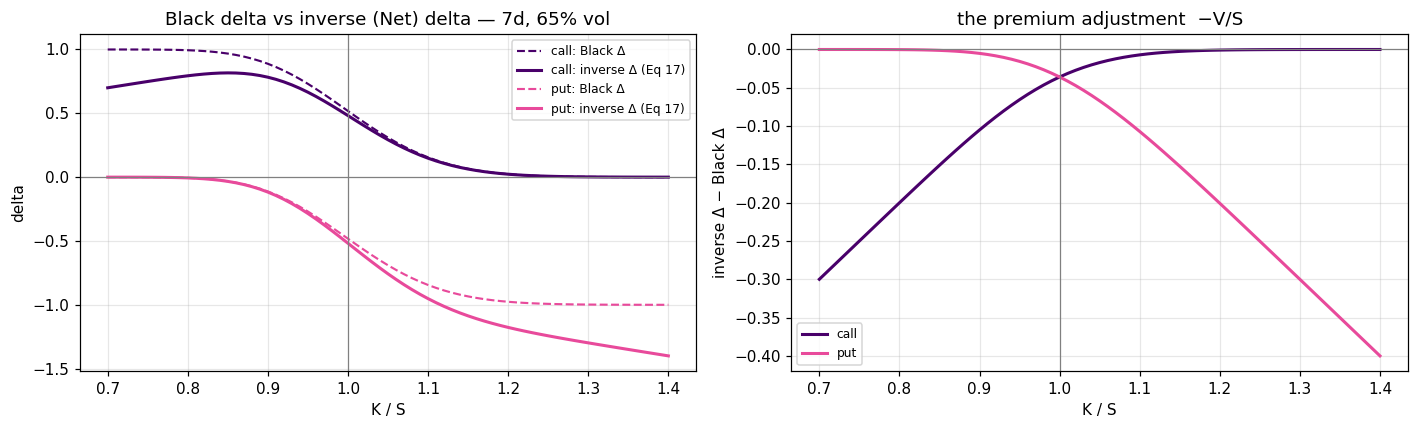

At the money: Black Δ(call) = +0.5179   inverse Δ = +0.4821   difference = -0.0359
The adjustment is the option's coin price V/S — largest for ITM options,
and it does NOT vanish at expiry for an in-the-money contract.


In [5]:
K = np.linspace(0.70, 1.40, 71)          # strike / spot (project's normalised convention)
T, r, q, sig = 7/365, 0.0, 0.0, 0.65      # 7-day option, 65% vol

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for otype, nm, col in [("c", "call", PALETTE[7]), ("p", "put", PALETTE[3])]:
    bd  = gk_delta(1.0, K, T, r, q, sig, otype)
    ind = inverse_delta(1.0, K, T, r, q, sig, otype)
    ax[0].plot(K, bd,  "--", color=col, lw=1.4, label=f"{nm}: Black Δ")
    ax[0].plot(K, ind, "-",  color=col, lw=2.0, label=f"{nm}: inverse Δ (Eq 17)")
    ax[1].plot(K, ind - bd, "-", color=col, lw=2.0, label=nm)
ax[0].axvline(1, color="grey", lw=.8); ax[0].axhline(0, color="grey", lw=.8)
ax[0].set(xlabel="K / S", ylabel="delta", title="Black delta vs inverse (Net) delta — 7d, 65% vol")
ax[0].legend(fontsize=8)
ax[1].axvline(1, color="grey", lw=.8); ax[1].axhline(0, color="grey", lw=.8)
ax[1].set(xlabel="K / S", ylabel="inverse Δ − Black Δ", title="the premium adjustment  −V/S")
ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

atm = np.argmin(abs(K - 1.0))
print(f"At the money: Black Δ(call) = {gk_delta(1.,1.,T,r,q,sig,'c'):+.4f}   "
      f"inverse Δ = {inverse_delta(1.,1.,T,r,q,sig,'c'):+.4f}   "
      f"difference = {inverse_delta(1.,1.,T,r,q,sig,'c')-gk_delta(1.,1.,T,r,q,sig,'c'):+.4f}")
print("The adjustment is the option's coin price V/S — largest for ITM options,")
print("and it does NOT vanish at expiry for an in-the-money contract.")

> **Trial & error.** An early version of the engine hedged with the plain Black delta.
> Every structure inherited a slow, systematic drift that looked like alpha in one
> direction and a cost in the other. It was neither — it was an unhedged −V/S.

### 2.4 What the results table reports

`roll_results.py` reproduces the paper's Table 1 layout. Conventions matter here because
they are what make the numbers comparable to the paper:

- **Vol / Sharpe / Skew** — daily log-returns of the Coin NAV, annualised by √365, zero
  risk-free rate.
- **α_AN / β / R²** — OLS of the strategy's **weekly** log-returns on the coin's weekly
  log-returns; α annualised ×52, R² adjusted.
- **Benchmark row** — the coin buy-and-hold, so β = 1, α = 0, R² = 1 by construction.

In [6]:
# The metric definitions, demonstrated on a synthetic NAV so the conventions are explicit.
rng = np.random.default_rng(0)
idx = pd.date_range("2025-01-01", periods=365, freq="D", tz="UTC")
nav = pd.Series(np.exp(np.cumsum(rng.normal(0.0004, 0.02, 365))), index=idx)
stats = RR._perf_stats(nav)
pd.Series(stats).to_frame("synthetic NAV — metric definitions").round(4)

,synthetic NAV — metric definitions
total_return,-0.0786
cagr,-0.0788
ann_vol,0.3876
sharpe,-0.2119
max_dd,-0.3811
skew,-0.0565
final,0.9240


<a id="sec3"></a>
## 3. Strategy results, and the diagnosis **[archive]**

Running the catalogue needs `clean_chunks_full`, which is on the desk machine. The numbers
below are from the recorded runs.

### 3.1 No strategy had a positive Sharpe

Across the full 26-strategy catalogue, on ETH and BTC, at weekly and monthly roll
frequencies, with realistic spread-crossing execution and realised funding: **no variant
produced a positive Sharpe ratio.**

That is not the same as "every strategy lost money". Several had positive total returns —
but so did holding the coin, and the whole point of a delta-hedged vol strategy is that it
should not need the coin to go up. Which brings us to the diagnosis.

### 3.2 The strategies traded direction, not volatility

Regressing weekly strategy returns on weekly coin returns:

| structure | β vs underlying | corr with spot |
|---|---|---|
| long call | **+0.13** | +0.81 |
| short call | **−0.13** | −0.80 |
| call-neutral structures (straddle, strangle, butterfly) | **−0.03** | — |

An hourly delta hedge removes delta. **It does not remove vanna** — the sensitivity of vega
to spot. A call-exposed structure therefore keeps a residual directional exposure, which
the +0.81 correlation with spot makes plain. The call-neutral structures come out at
β = −0.03, which confirms the mechanism rather than contradicting it.

### 3.3 Where the residual beta comes from

Vanna is $\partial^2 V/\partial S\,\partial\sigma$. Between hedges, the P&L a
delta-hedged book picks up from it is approximately

$$\text{vanna} \times \Delta\sigma \times \Delta S$$

and $\Delta\sigma$ is itself driven by $\Delta S$ through the **spot–vol correlation**.
So the residual beta is (vanna) × (spot–vol correlation). That is precisely the quantity
§8 goes on to measure.

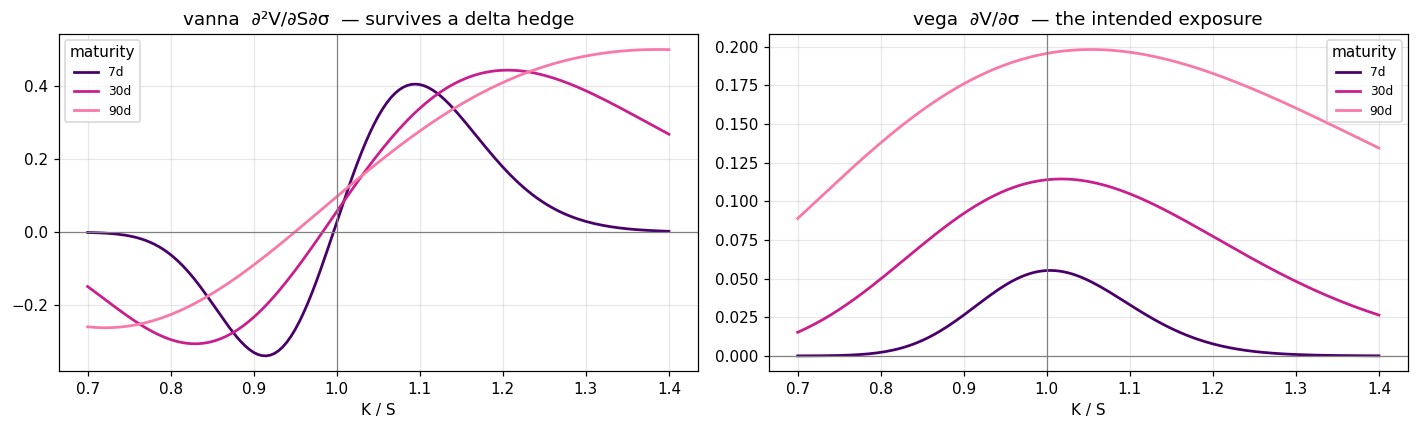

Vanna changes sign through the money and is largest in the wings — exactly where
the 25D/10D structures sit. A delta hedge zeroes delta and leaves this untouched.


In [7]:
K = np.linspace(0.70, 1.40, 141)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for T_, lbl, col in [(7/365, "7d", PALETTE[7]), (30/365, "30d", PALETTE[4]),
                     (90/365, "90d", PALETTE[2])]:
    ax[0].plot(K, gk_vanna(1.0, K, T_, 0, 0, 0.65), color=col, lw=1.8, label=lbl)
    ax[1].plot(K, gk_vega(1.0, K, T_, 0, 0, 0.65), color=col, lw=1.8, label=lbl)
for a, t in zip(ax, ["vanna  ∂²V/∂S∂σ  — survives a delta hedge",
                     "vega  ∂V/∂σ  — the intended exposure"]):
    a.axvline(1, color="grey", lw=.8); a.axhline(0, color="grey", lw=.8)
    a.set(xlabel="K / S", title=t); a.legend(fontsize=8, title="maturity")
plt.tight_layout(); plt.show()

print("Vanna changes sign through the money and is largest in the wings — exactly where")
print("the 25D/10D structures sit. A delta hedge zeroes delta and leaves this untouched.")

### 3.4 Why regime switching does not rescue it

The obvious next move is to switch structures on a market-state signal. `regime_hmm.py`
implements a Gaussian HMM for exactly that, and it works as a *classifier*: 77% state
persistence, 98.8% walk-forward accuracy on known states, with a strict separation between

- **filtered** $P(s_t \mid x_1..x_t)$ — uses only the past, tradeable;
- **smoothed** $P(s_t \mid x_1..x_T)$ — uses the whole sample, **descriptive only**.

`hmmlearn.predict()` (Viterbi) is smoothed. A backtest built on it looks excellent and
means nothing. The module names the smoothed accessor so it cannot be used by accident.

But the premium is **zero in both states** (§9.4), so there is nothing to switch between.
And the module's own docstring makes the sharper point:

> switching between long-call and short-call structures on a state signal is directional
> timing wearing an options costume — and one that pays an ~11% option spread to express
> what the perp expresses for 5 bp.

That 11%-vs-5bp comparison is, in the end, the most practical finding of the whole
strategy programme.

<a id="sec4"></a>
## 4. Realised volatility: four estimators and the discretisation loss

If a delta-hedged position earns realised variance, *which* realised variance? The engine
hedges hourly, so the answer is not obvious — and the four estimators in
`vrp_signal.perp_variance` disagree by 3–6 vol points.

| estimator | reads | measures |
|---|---|---|
| `close` | $\log(c_t/c_{t-1})^2$ | quadratic variation **at the sampling frequency** — what an hourly hedger earns |
| `parkinson` | $\log(h/l)^2/(4\log 2)$ | latent continuous volatility, from the bar range |
| `garman_klass` | range + $\log(c/o)^2$ | same, more efficient |
| `rogers_satchell` | range + open/close | same, robust to intrabar drift |

`close` is the only one a discretely hedged position monetises. The others see variation
happening **inside** the hedging interval. The difference is the **discretisation loss**.

In [8]:
rv14 = SV.realised_vol_by_estimator(PERP, spot.index, V.ESTIMATORS,
                                    window_days=14, bar_freq="1h")
panel = rv14.copy()
panel["spot"] = spot
panel.attrs.update(rv_window=14, bar_freq="1h")
panel = panel.dropna(subset=["spot"])
print("Annualised vol, 14-day trailing window on 1h bars (vol points)")
SV.levels(panel)

Annualised vol, 14-day trailing window on 1h bars (vol points)


,n,mean,median,min,max,std,vs_close
series,,,,,,,
rv_close,793,64.60,62.87,25.08,116.00,17.85,0.00
rv_parkinson,794,67.75,64.82,23.26,128.22,20.12,3.14
rv_garman_klass,794,68.90,65.74,24.32,134.16,21.07,4.30
rv_rogers_satchell,794,70.66,66.74,24.65,146.16,22.68,6.06


`vs_close` is the discretisation loss: **an hourly hedger on ETH gives up 3–6 vol points**
of variation the underlying genuinely realised but that never appears between rebalances.
It is **not a constant offset** — near zero at ~50% vol, ~15 points at the peaks.

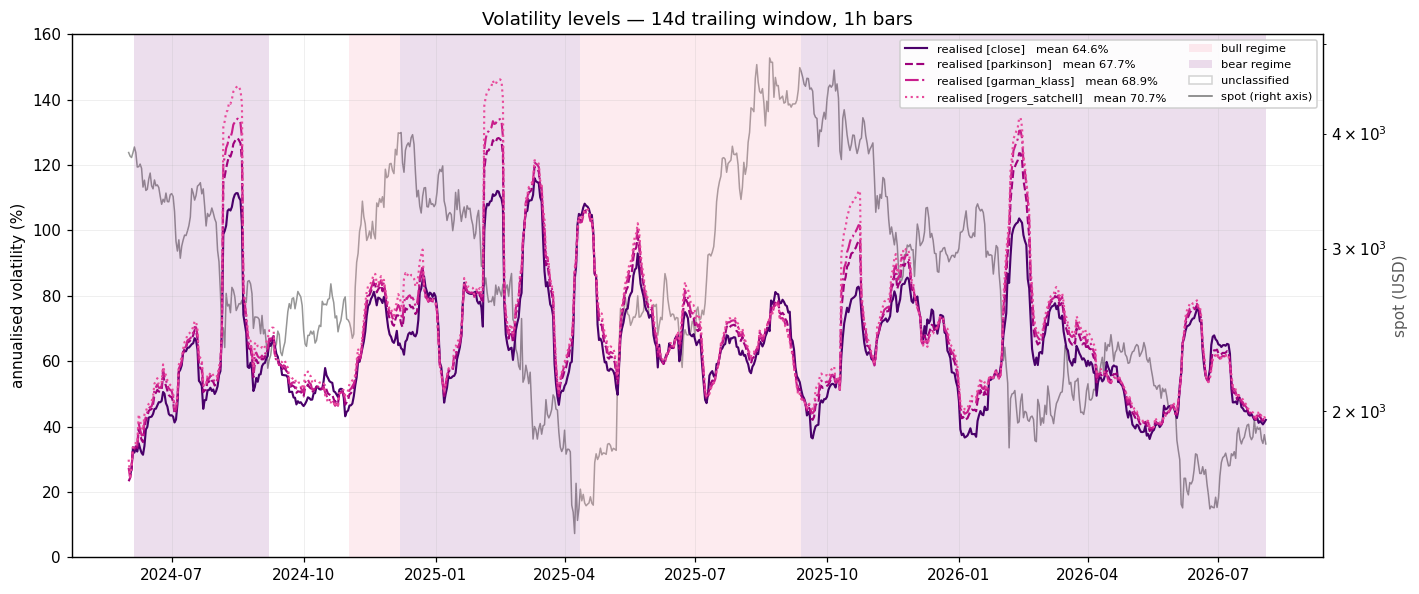

In [9]:
SV.plot_levels(panel, regimes=R.REGIMES, log_spot=True, implied=False, ylim=(0, 160))

> **Trial & error.** The first version of this chart used `rv_window=1`, producing an
> unreadable picket fence between 20% and 120%. Clipping the axis did not help, because the
> problem was not the axis: a 1-day window on hourly bars is 24 observations, carrying
> **29% relative standard error**. Raising it to 14 days (336 bars, 8% s.e.) fixed it.
> Levels and correlations want *different* windows — see §5.

<a id="sec5"></a>
## 5. The spot–vol correlation: two parameter traps

This section exists because it consumed more time than any other part of the project, and
both traps produce a plausible-looking wrong answer rather than an error.

### Trap 1 — a window that changed units

`spot_vol_corr.build(rv_window=...)` originally took a **count of bars**; it was later
changed to **calendar days**. Same name, same call site, different meaning. A measured
correlation moved from **−0.02 to −0.18** with nothing else altered. Neither was wrong —
they answered different questions.

### Trap 2 — a correlation window too short to resolve the effect

`rolling(window_days=n)` sets the **sample size of each estimate**, not what is measured.
Smallest correlation distinguishable from zero at $p<0.05$:

| n | smallest detectable \|ρ\| |
|---|---|
| 5 | 0.88 |
| 30 | 0.36 |
| 90 | 0.21 |
| 180 | 0.15 |

At one point we were hunting an effect of ~0.2 with `n=5`, which returns ±1 noise by
construction.

In [10]:
rows = []
ret = np.log(spot / spot.shift(1))
for w in (1, 5, 30):
    rv = SV.realised_vol_by_estimator(PERP, spot.index, ("close",), w, "1h")["rv_close"]
    d = rv.diff()
    for rw in (5, 30, 90, 180):
        rc = ret.rolling(rw).corr(d).dropna()
        rows.append({"rv_window": w, "window_days": rw, "std": rc.std(),
                     "share |corr|>0.9": float((rc.abs() > 0.9).mean()),
                     "min": rc.min(), "max": rc.max()})
pd.DataFrame(rows).set_index(["rv_window", "window_days"]).round(3)

std  share |corr|>0.9    min    max
rv_window window_days                                       
1         5            0.491             0.034 -0.989  0.989
          30           0.210             0.000 -0.483  0.431
          90           0.139             0.000 -0.311  0.233
          180          0.091             0.000 -0.245  0.100
5         5            0.473             0.027 -0.980  0.989
          30           0.158             0.000 -0.421  0.502
          90           0.083             0.000 -0.218  0.226
          180          0.043             0.000 -0.123  0.109
30        5            0.493             0.051 -0.985  0.976
          30           0.195             0.000 -0.642  0.562
          90           0.108             0.000 -0.340  0.208
          180          0.068             0.000 -0.160  0.071

Every `window_days=5` row hits ±0.98 regardless of `rv_window`. The instability is
entirely the correlation window.

### The overlap trade-off

There is no free choice of `rv_window`: short windows remove overlap between consecutive
observations but add estimation noise; long windows do the reverse.

In [11]:
rows = []
for w in (1, 3, 7, 14, 30):
    rv = SV.realised_vol_by_estimator(PERP, spot.index, ("close",), w, "1h")["rv_close"]
    nb_ = 24 * w
    rows.append({"rv_window": w, "bars/obs": nb_, "rel. s.e.": f"{100*np.sqrt(2/nb_):.0f}%",
                 "hours shared": max(0, nb_ - 24),
                 "ac1(level)": rv.autocorr(1), "ac1(diff)": rv.diff().autocorr(1),
                 "eff. obs in a 90-window": 90 / w})
pd.DataFrame(rows).set_index("rv_window").round(3)

,bars/obs,rel. s.e.,hours shared,ac1(level),ac1(diff),eff. obs in a 90-window
rv_window,,,,,,
1,24,29%,0,0.424,-0.348,90.000
3,72,17%,48,0.850,0.228,30.000
7,168,11%,144,0.951,0.306,12.857
14,336,8%,312,0.978,0.343,6.429
30,720,5%,696,0.991,0.265,3.000


At `rv_window=30` a 90-observation rolling correlation rests on roughly **3 independent
observations**. That is the staircase we spent a session interpreting as signal.

Note `ac1(diff)`: **negative at `rv_window=1`, positive from 3 upward** — the signature of
non-overlap, which matters in §7.

<a id="sec6"></a>
## 6. Data audit, and one contaminated input

In [12]:
d = pd.read_parquet(PERP)
d.index = pd.to_datetime(d["timestamp_ms"], unit="ms", utc=True)
span = d.index.max() - d.index.min()
expected = int(span.total_seconds() / 60) + 1
gaps = d.index.to_series().diff()
pd.Series({
    "1-min bars":            f"{len(d):,}",
    "expected bars":         f"{expected:,}",
    "missing":               f"{expected - len(d):,}",
    "duplicated timestamps": int(d["timestamp_ms"].duplicated().sum()),
    "gaps > 5 min":          int((gaps > pd.Timedelta('5min')).sum()),
    "span (days)":           f"{span.total_seconds()/86400:.1f}",
    "zero-range bars":       f"{(d['high']==d['low']).sum():,} ({(d['high']==d['low']).mean():.2%})",
    "OHLC violations":       int((d['high'] < d['low']).sum()),
}, name="value").to_frame()

,value
1-min bars,"1,142,674"
expected bars,"1,142,674"
missing,0
duplicated timestamps,0
gaps > 5 min,0
span (days),793.5
zero-range bars,"86,439 (7.56%)"
OHLC violations,0


Zero missing minutes over 793.5 days. The 7.6% zero-range bars are thin minutes where a
single price traded, not corrupt data.

### Liquidation wicks — the range estimators' exposure

In [13]:
body = (d["close"] - d["open"]).abs()
ratio = ((d["high"] - d["low"]) / body.replace(0, np.nan)).dropna()
print("(high-low)/|close-open| quantiles"); print(ratio.quantile([.5,.9,.99,.999,.9999]).round(2).to_string())
print(f"\ntop 0.1%: {int((ratio > ratio.quantile(.999)).sum()):,} bars\n")
d.loc[ratio.nlargest(5).index, ["open","high","low","close"]].assign(ratio=ratio.nlargest(5).values).round(2)

(high-low)/|close-open| quantiles
0.5000      1.33
0.9000      5.00
0.9900     27.00
0.9990     77.00
0.9999    150.21

top 0.1%: 1,034 bars



,open,high,low,close,ratio
timestamp_ms,,,,,
2025-10-10 21:49:00+00:00,3799.90,3856.15,3781.45,3800.00,747.00
2025-03-02 16:41:00+00:00,2410.95,2418.25,2388.55,2411.00,594.00
2025-10-10 21:02:00+00:00,3895.05,3904.70,3880.00,3895.10,494.00
2025-02-02 22:41:00+00:00,2806.40,2809.90,2742.65,2806.55,448.33
2025-10-11 01:47:00+00:00,3762.20,3778.55,3761.15,3762.15,348.00


**Three of the five most extreme minutes in two years fall on 2025-10-10/11** — the
October 2025 liquidation cascade. Parkinson/GK/RS all read the high and the low, so these
non-tradeable prints flow straight in. §8 tests whether the headline survives dropping
them (it does).

### Intraday seasonality

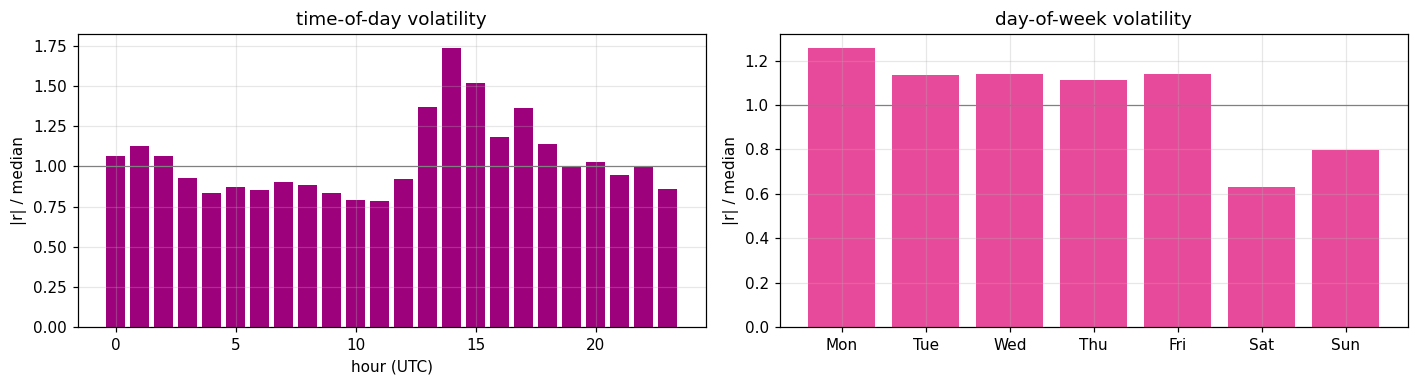

time-of-day amplitude : 2.21x vol, 4.90x variance
ANOVA mean return across hours : F= 1.35  p=0.121   <- NOT significant
ANOVA |return|    across hours : F=26.04  p=5.4e-110  <- overwhelming


In [14]:
r1h = np.log(d["close"].resample("1h").last().ffill()).diff().dropna()
a = r1h.to_frame("r"); a["hour"] = a.index.hour; a["dow"] = a.index.dayofweek
tod = a.groupby("hour")["r"].apply(lambda x: x.abs().median()) / a["r"].abs().median()
dow = a.groupby("dow")["r"].apply(lambda x: x.abs().median()) / a["r"].abs().median()
from scipy import stats
F_m, p_m = stats.f_oneway(*[g["r"].values for _, g in a.groupby("hour")])
F_a, p_a = stats.f_oneway(*[np.abs(g["r"].values) for _, g in a.groupby("hour")])

fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
ax[0].bar(tod.index, tod.values, color=PALETTE[5]); ax[0].axhline(1, color="grey", lw=.8)
ax[0].set(xlabel="hour (UTC)", ylabel="|r| / median", title="time-of-day volatility")
ax[1].bar(range(7), dow.values, color=PALETTE[3]); ax[1].axhline(1, color="grey", lw=.8)
ax[1].set_xticks(range(7)); ax[1].set_xticklabels(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])
ax[1].set(ylabel="|r| / median", title="day-of-week volatility")
plt.tight_layout(); plt.show()
print(f"time-of-day amplitude : {tod.max()/tod.min():.2f}x vol, {(tod.max()/tod.min())**2:.2f}x variance")
print(f"ANOVA mean return across hours : F={F_m:5.2f}  p={p_m:.3f}   <- NOT significant")
print(f"ANOVA |return|    across hours : F={F_a:5.2f}  p={p_a:.1e}  <- overwhelming")

Volatility is strongly seasonal (peak 13:00–15:00 UTC, the US cash open); the **mean
return is not**. The classic spurious-correlation mechanism needs *both* seasonal, so at
the daily horizon this is a weak contaminant.

### ⚠️ The contaminated input

In [15]:
src = inspect.getsource(R)
print(src[src.index("# Market regimes"):src.index("def _to_ms")].strip()[:1050])

# Market regimes
# --------------------------------------------------------------------------- #
#: Hand-labelled ETH regimes over the 2024-2026 dataset, as (start, end) UTC
#: dates. Deliberately NOT derived from the data: the paper's own regime split
#: (Fig 8/9) sorts monthly returns and cuts the tails at 16%, which is circular
#: when the question is "does this strategy survive a regime it did not fit to".
#: These are the user's own reading of the market and are meant to be edited.
#: Note the gaps (e.g. 2024-09-07 -> 2024-11-02) — those months belong to
#: neither camp and are simply excluded from a regime run.
REGIMES: dict[str, tuple[str, str]] = {
    "bear1": ("2024-06-05", "2024-09-07"),
    "bear2": ("2024-12-07", "2025-04-12"),
    "bear3": ("2025-09-13", "2026-08-03"),
    "bull1": ("2024-11-02", "2024-12-07"),
    "bull2": ("2025-04-12", "2025-09-13"),
}


**Hand-drawn from the finished price chart** — `bear2` runs local top to local bottom.
That is peak-to-trough labelling, which encodes the future.

**Every regime-conditional statistic computed against `R.REGIMES` is contaminated by
hindsight.** They stay useful as chart *shading*, which is how this notebook uses them.
For statistics we use a causal replacement: trailing drawdown from a running max.

In [16]:
reg_causal = LEV.causal_regimes(spot)
print("causal regimes (trailing 90-day drawdown from running max):")
print(reg_causal.value_counts().to_string())

causal regimes (trailing 90-day drawdown from running max):
regime_causal
drawdown     434
neutral      264
near-high     96


<a id="sec7"></a>
## 7. Monte Carlo: what the pipeline can actually see

The step that changed the conclusion, and it should have come first. Simulate a process
with a **known** $\rho = \mathrm{corr}(dW_S, dW_v)$, run the identical estimator, see what
comes back. Heston, 5-minute steps, 794 days to match the sample, 12 paths per ρ.

In [17]:
mc = LEV.mc_recovery(rhos=(-0.8, -0.5, -0.2, 0.0, 0.3), n_days=794,
                     n_paths=12, steps_per_day=288)
mc[["clean_mean","clean_sd","clean_lo","clean_hi","sv_mean","frac_clean_negative"]].round(4)

,clean_mean,clean_sd,clean_lo,clean_hi,sv_mean,frac_clean_negative
true_rho,,,,,,
-0.8,-0.3069,0.0385,-0.3525,-0.2472,0.0055,1.0000
-0.5,-0.2011,0.0325,-0.2412,-0.1566,0.0016,1.0000
-0.2,-0.0725,0.0341,-0.1232,-0.0308,-0.0013,1.0000
0.0,0.0154,0.0339,-0.0311,0.0622,-0.0015,0.3333
0.3,0.1278,0.0288,0.0759,0.1566,-0.0046,0.0000


### 7a. The correlation estimator works, but is attenuated ~2.5×

`corr(r_t, Δlog RV_{t+1})` is **monotone in ρ, tight (sd ≈ 0.03), correctly signed in 100%
of paths at every negative ρ tested** — including ρ = −0.2. It passes.

But it is shrunk toward zero by a factor of ≈ **0.40**. Intrinsic, not a bug: daily RV is a
noisy estimate of integrated variance, the noise is independent of the return, and
errors-in-variables attenuates any correlation built on it. **Divide an observed
correlation by 0.40 to read it as ρ.**

### 7b. Signed variation is blind to a diffusive leverage effect

We expected $(RS^+ - RS^-)/RV$ — realised semivariance, no correlation coefficient, no
attenuation — to be the cleanest estimand. **The simulation refutes that.** At ρ = −0.8 it
reads **+0.0055, the wrong sign**, moving only 0.01 across the whole range with no monotone
ordering.

Structural reason: in a diffusion, returns are conditionally symmetric given the current
variance level, whatever the correlation between driving Brownians. Signed variation
detects **asymmetric jumps** — a different mechanism.

> **Trial & error, and the lesson of the project.** A null from signed variation is not
> evidence against a leverage effect. Without simulating first we would have reported "no
> asymmetry in ETH" on the strength of an estimator that cannot see the thing we asked it
> about.

### 7c. Could the rolling correlation have been trusted?

In [18]:
sim = LEV.simulate_heston(-0.7, 794, 288, n_paths=12, seed=7)
share_above, means = [], []
for _, g in sim.groupby("path"):
    g = g.sort_values("day")
    rc = g["ret"].rolling(90).corr(np.log(g["rv"]).diff().shift(-1)).dropna()
    share_above.append(float((rc > 0).mean())); means.append(rc.mean())
print("true rho = -0.70, 90-observation rolling window, 12 paths:")
print(f"  mean rolling correlation          {np.mean(means):+.3f}")
print(f"  share of windows above zero       {np.mean(share_above):.1%}")
print(f"  paths crossing zero at least once {sum(s > 0 for s in share_above)}/12")

true rho = -0.70, 90-observation rolling window, 12 paths:
  mean rolling correlation          -0.280
  share of windows above zero       0.0%
  paths crossing zero at least once 0/12


**A genuinely strong leverage effect would never have produced the near-zero rolling plot
we spent weeks interpreting.** At ρ = −0.7 the estimate sits at −0.28 and does not touch
zero across ~8,400 window-observations. The flat plot was **the correct answer to a
question asked with too little precision**.

<a id="sec8"></a>
## 8. The leverage effect, properly measured

Realised variance built **per calendar day from 288 five-minute returns** —
non-overlapping, 8.3% relative standard error, no trailing window.

| estimand | definition | status |
|---|---|---|
| contaminated | $\mathrm{corr}(r_t, \Delta\log RV_t)$ | $r_t$ sits **inside** $RV_t$ → a realised-skewness estimator |
| clean | $\mathrm{corr}(r_t, \Delta\log RV_{t+1})$ | no mechanical link — the honest proxy |
| LHAR $\gamma_d$ | coefficient on $r^-_t$ | controls vol persistence — the primary test |

In [19]:
r5 = LEV.intraday_returns(PERP, "5min")
daily = LEV.daily_measures(r5)
print(f"{len(daily)} days | {int(daily['n_obs'].median())} obs/day | "
      f"mean RV {daily['rv_ann'].mean():.1%} | jumps {(daily['jump']/daily['rv']).mean():.1%} of RV")
e1 = LEV.e1_correlations(daily)
e1[["rho","n","n_eff","boot_lo","boot_hi","p_neff"]].round(4)

794 days | 288 obs/day | mean RV 62.3% | jumps 7.7% of RV


,rho,n,n_eff,boot_lo,boot_hi,p_neff
measure,,,,,,
"CONTAMINATED corr(r_t, dlogRV_t) [= skewness]",-0.0932,793,638.1350,-0.1845,-0.0067,0.0182
"CLEAN corr(r_t, dlogRV_t+1)",-0.0851,793,1040.0940,-0.1483,-0.0176,0.0059
"CLEAN corr(r_t, dlogBV_t+1) [jump-robust]",-0.0624,793,1077.8866,-0.1252,0.0075,0.0403
"CLEAN corr(r_t, dlogMedRV_t+1) [jump-robust]",-0.0452,793,1111.8676,-0.1087,0.0252,0.1320


In [20]:
placebo = LEV.placebo_null(daily)
print("Placebo null — returns shuffled, marginals preserved, 2000 replicates:")
print(f"  corr 95% null band  [{placebo['corr_p2.5']:+.4f}, {placebo['corr_p97.5']:+.4f}]")
print(f"  observed clean corr  {e1.loc['CLEAN  corr(r_t, dlogRV_t+1)','rho']:+.4f}  <- outside the band")
print("\nSigned variation (relabelled: signed JUMP asymmetry, per 7b):")
LEV.e5_signed_variation(daily).round(5)

Placebo null — returns shuffled, marginals preserved, 2000 replicates:
  corr 95% null band  [-0.0695, +0.0736]
  observed clean corr  -0.0851  <- outside the band

Signed variation (relabelled: signed JUMP asymmetry, per 7b):


,estimate,hac_se,nw_lags,t_stat,p_value,ci_lo,ci_hi,n
measure,,,,,,,,
E5 mean (RS+ - RS-)/RV [per-day],-0.00249,0.00695,6.0,-0.35833,0.72009,-0.01612,0.01113,794
mean realised skewness,-0.01976,0.04749,6.0,-0.41608,0.67735,-0.11283,0.07331,794
pooled (sum RS+ - sum RS-)/sum RV,-0.01548,NaN,NaN,NaN,NaN,NaN,NaN,794


### The primary test — LHAR (Corsi–Renò)

$$\log RV_{t+1} = c + \text{HAR}(\log RV) + \gamma_d r^-_t + \gamma_w r^-_{t-4:t}
+ \gamma_m r^-_{t-21:t} + \gamma_p r^+_t$$

In [21]:
lh = LEV.lhar(daily)
print(f"R2 = {lh.attrs['r2']:.4f}   n = {lh.attrs['n']}")
lh.round(4)

R2 = 0.3756   n = 772


,coef,hac_se,t,p,ci_lo,ci_hi
const,-2.4433,0.5054,-4.8345,0.0000,-3.4339,-1.4528
lv_d,0.3267,0.0381,8.5812,0.0000,0.2521,0.4014
lv_w,0.0419,0.0793,0.5282,0.5974,-0.1135,0.1973
lv_m,0.3088,0.0930,3.3220,0.0009,0.1266,0.4910
rn_d,-8.7536,1.5191,-5.7625,0.0000,-11.7309,-5.7763
rn_w,-8.4002,3.8689,-2.1712,0.0299,-15.9831,-0.8172
rn_m,6.2141,5.0981,1.2189,0.2229,-3.7779,16.2062
rp_d,3.0886,1.1721,2.6350,0.0084,0.7913,5.3859


$\gamma_d = -8.75$, $t = -5.76$. In economic terms:

- a **−1% day raises next-day realised variance by 8.8%** (vol ~4.3%)
- a **+1% day raises it by 3.1%** (vol ~1.5%)

Both raise volatility — the magnitude effect — but **down moves 2.8× more**. That ratio is
the leverage effect.

In [22]:
ratio = 0.399
obs, lo_, hi_ = -0.0851, -0.1491, -0.0162
print(f"observed clean correlation   {obs:+.4f}   bootstrap CI [{lo_:+.4f}, {hi_:+.4f}]")
print(f"attenuation factor (MC)       {ratio:.3f}")
print(f"\nIMPLIED rho = corr(dW_S, dW_v)  {obs/ratio:+.3f}   CI [{lo_/ratio:+.3f}, {hi_/ratio:+.3f}]")
print("equity index benchmark        -0.60 to -0.80  (literature)")

observed clean correlation   -0.0851   bootstrap CI [-0.1491, -0.0162]
attenuation factor (MC)       0.399

IMPLIED rho = corr(dW_S, dW_v)  -0.213   CI [-0.374, -0.041]
equity index benchmark        -0.60 to -0.80  (literature)


$$\boxed{\rho_{\text{ETH}} \approx -0.21,\quad 95\%\ \text{CI}\ [-0.37,\ -0.04]}$$

**Real, negative, and roughly one third the strength of an equity index.** This is the
number behind the vanna exposure in §3.3 — a weak, unstable leverage effect gives a thin,
unstable vanna edge, which is why the residual betas came out at only ±0.13.

### The shape

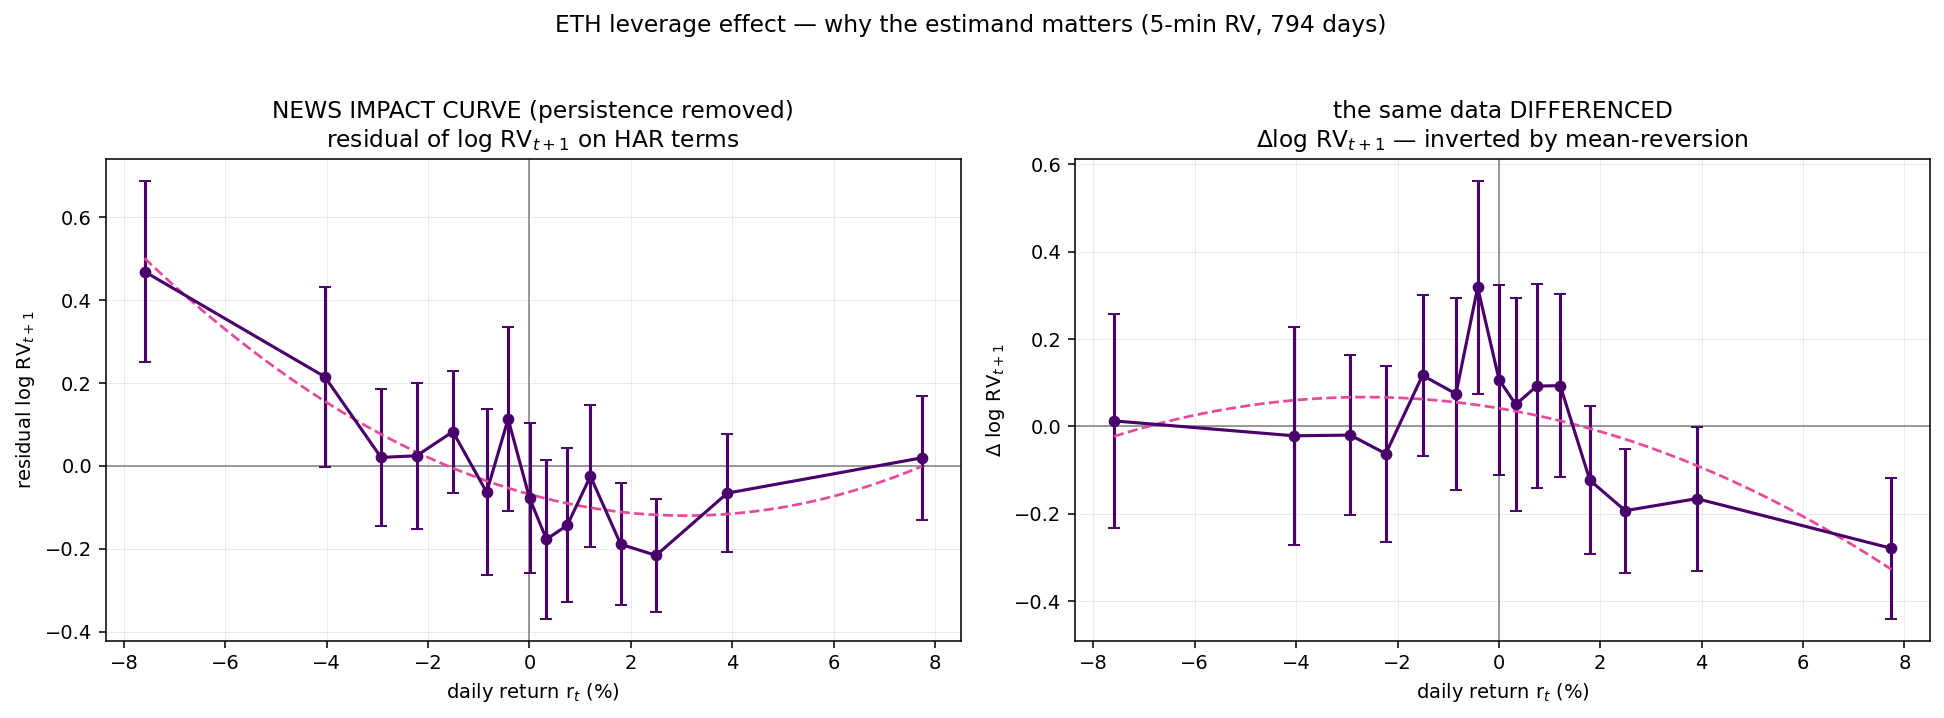

In [23]:
from IPython.display import Image, display
display(Image(str(RESULTS / "figures" / "leverage_shape.png")))

In [24]:
ht = LEV.horizon_term_structure(PERP, "5min")
ht[["n","corr_clean","corr_lo","corr_hi","sv_ratio","sv_t"]].round(4)

,n,corr_clean,corr_lo,corr_hi,sv_ratio,sv_t
horizon,,,,,,
1h,19043,-0.0322,-0.0485,-0.0170,0.0073,2.2527
4h,4761,-0.0195,-0.0480,0.0092,0.0067,1.5021
12h,1587,-0.0072,-0.0425,0.0367,0.0059,1.0116
1D,794,-0.0851,-0.1491,-0.0162,-0.0025,-0.3583
3D,265,0.0594,-0.0383,0.1715,-0.0034,-0.4203
7D,114,0.0786,-0.0652,0.2062,-0.0098,-0.9647


**The effect peaks at the daily horizon and vanishes beyond it** — significant at 1h and
1D, indistinguishable from zero at 4h/12h, positive (CIs spanning zero) at 3D and 7D.
**The opposite of equities**, where the leverage effect strengthens with horizon.

### Robustness

In [25]:
print("Influence — is this a handful of liquidation cascades?")
display(LEV.influence_drop(daily).round(4))
print("\nPooled by CAUSAL regime (not the hand-labelled ones):")
display(LEV.by_regime(daily, reg_causal).round(4))

Influence — is this a handful of liquidation cascades?


,n,sv_ratio,sv_se,sv_t,corr_clean
sample,,,,,
all days,794,-0.0025,0.007,-0.3583,-0.0851
drop top 3 |r| days,791,-0.0025,0.007,-0.3629,-0.0874



Pooled by CAUSAL regime (not the hand-labelled ones):


,n,mean_rv_ann,sv_ratio,sv_se,sv_t,corr_clean,n_eff,boot_lo,boot_hi
regime,,,,,,,,,
drawdown,434,0.6567,-0.0036,0.0090,-0.3954,-0.1204,604.7080,-0.1982,-0.0405
near-high,96,0.6309,0.0735,0.0164,4.4876,-0.2060,67.2967,-0.4195,0.0303
neutral,264,0.5642,-0.0284,0.0125,-2.2732,0.0059,263.0000,-0.0993,0.1124


**Not cascade-driven:** dropping the 3 largest $|r|$ days moves the correlation from
−0.0851 to −0.0874. The October 2025 wicks do not carry it.

**Regimes cannot be distinguished.** `near-high` reads −0.206 against `drawdown` −0.120,
but `near-high` has $n_{\text{eff}} = 67$ and a CI of $[-0.42, +0.03]$. 794 days with a
vol half-life of ~3 weeks contains perhaps **4–6 independent macro episodes**.

**Multiple testing.** ~25 tests across estimators, horizons and regimes. Under Holm the
LHAR result ($p < 10^{-8}$) survives comfortably; the headline correlation ($p = 0.0059$)
**does not** survive family-wise correction alone. The conclusion rests on the LHAR.

<a id="sec9"></a>
## 9. The volatility risk premium: nothing to harvest **[archive]**

Recorded from `vrp_signal.py` / `regime_hmm.py` runs on the full options archive.

### 9.1 The premium is zero

| quantity | value |
|---|---|
| mean ATM implied vol (30d constant maturity) | 62.9% |
| mean subsequent realised vol | 63.7% |
| **premium (IV − RV)** | **−0.82%** |
| t-statistic | **−0.44** |
| 95% CI | [−4.5%, +2.8%] vol points |

**Negative, tiny, indistinguishable from zero.** Options were on average very slightly
*cheap*. There is nothing to sell — which is the direct explanation for §3.1.

### 9.2 The RV > IV signal has no predictive power

The natural rule — "enter when recent realised vol exceeds implied" — needs
$RV_{\text{past}} - IV$ to predict $RV_{\text{future}} - IV$. It does not:

| statistic | value |
|---|---|
| correlation | +0.127 |
| t-statistic | 1.25 |
| $R^2$ | 1.6% |

ETH realised vol **is** persistent (weekly autocorrelation +0.27), so "vol has been high"
does predict "vol will be high". But implied vol already knows that — market makers see the
same history. The signal only has value if the market **under-reacts**, and it doesn't.

### 9.3 The premium under each realised-vol estimator

`vrp_signal.compare_estimators` reruns the measurement under all four. The `vs_close`
column is the discretisation loss of §4, expressed as premium: the part of the theoretical
premium that an hourly hedger structurally cannot capture.

### 9.4 Regime conditioning does not rescue it

The HMM separates low- and high-vol states cleanly (77% persistence, 98.8% walk-forward
accuracy). **The premium is zero in both.** There is no regime in which selling vol
worked.

<a id="sec10"></a>
## 10. Trials & errors

The honest version. Every one produced a plausible wrong answer rather than an error.

1. **Hedging an inverse option with the plain Black delta.** Missing the $-V/S$ premium
   adjustment (Eq 17) gave every structure a slow systematic drift that read as alpha one
   way and cost the other. **Lesson:** the numeraire is part of the instrument.

2. **A parameter that changed units.** `rv_window` went from a bar count to calendar days.
   Same name, same call, and a measured correlation moved −0.02 → −0.18. **Lesson:** when a
   unit changes, rename the parameter.

3. **A correlation window too short to resolve the effect.** We ran `window_days=5` and read
   the resulting ±1 sawtooth as signal. At n=5 the smallest detectable $|\rho|$ is **0.88**;
   we were hunting 0.2.

4. **Interpreting an estimator before calibrating it.** Weeks spent reading a rolling
   correlation that Monte Carlo later showed to be attenuated 2.5× and, at n=90, unable to
   distinguish −0.2 from zero. **The simulation should have come first.**

5. **Trusting the "clean" estimand.** Signed variation was chosen precisely because it
   avoids a correlation coefficient — and it is blind to diffusive leverage, returning the
   *wrong sign* at ρ = −0.8. Elegance is not validity.

6. **A hindsight-labelled input.** `R.REGIMES` was hand-drawn peak-to-trough from the
   finished chart, and every regime statistic built on it was contaminated. Look-ahead
   arrives through the inputs you didn't think of as estimates.

7. **Smoothed HMM states.** `hmmlearn.predict()` is Viterbi, i.e. smoothed — a backtest on
   it looks excellent and means nothing. Fixed with `walk_forward_states`, which also
   refits parameters on an expanding window.

8. **A library function that hijacked the backend.** `matplotlib.use("Agg")` inside a
   plotting helper switched the whole kernel headless, silently swallowing every figure.
   Process-wide state does not belong in a library function.

9. **Throwing away 59/60ths of the data.** The pipeline aggregated 1-minute bars to hourly
   and sampled daily — 24 observations per RV estimate at 29% relative standard error, when
   1,440 were available at 3.7%.

<a id="sec11"></a>
## 11. Conclusion: a catalogue of well-measured zeros

**What is real:**

- **ETH has a negative leverage effect: ρ ≈ −0.21, CI [−0.37, −0.04].** Primary evidence
  LHAR $\gamma_d = -8.75$, $t = -5.76$, $p < 10^{-8}$. A −1% day raises next-day variance
  8.8% against 3.1% for a +1% day.
- **The discretisation loss is 3–6 vol points** for an hourly hedger, and state-dependent:
  near zero at 50% vol, ~15 points at the peaks.
- **The inverse-option delta correction is material** and is the difference between a
  hedged and a systematically drifting book.
- **The perp data is exceptionally clean** — zero missing minutes over 793.5 days.

**What is zero, measured carefully enough to say so:**

- Sharpe of **all 26 systematic strategies**, both sides, weekly and monthly, ETH and BTC.
- The volatility risk premium: **−0.82%, t = −0.44**.
- Predictive power of RV > IV: $R^2$ **1.6%**, t = 1.25.
- Volatility feedback — vol shocks predicting returns: **nothing** at any horizon 1–10 days.
- Signed jump asymmetry: **−0.0025, p = 0.72**.
- Unconditional return skew: **+0.15** — ETH is *positively* skewed over this sample.
- Any regime difference in the leverage effect: **not distinguishable**, ~4–6 independent
  episodes.

**Why the strategies failed, in one paragraph.** There was no premium to harvest
(−0.82%, t = −0.44), so the intended P&L source was absent. What remained was a residual
directional exposure through vanna (β = ±0.13, spot correlation ±0.80), driven by a
spot–vol correlation that is real but weak (ρ ≈ −0.21). Against that, execution costs an
~11% option spread where the perp costs 5 bp. The strategies were paying a large, certain
cost to express a small, uncertain edge in the most expensive available instrument.

**What we cannot say from this data:**

- Whether options *price* the leverage effect correctly. That needs the implied side —
  $\partial\sigma_{ATM}/\partial\log F$, the skew-stickiness ratio, and the
  implied-versus-realised ρ gap (the skew risk premium). **The single highest-value
  remaining measurement**, and §8 gives it a baseline.
- Whether the leverage effect is stable out of sample. It peaks daily, vanishes by 3 days,
  and behaves oppositely to equities. One 26-month sample cannot separate "ETH" from
  "2024–2026".

**Next steps, in order of expected value:**

1. Build the constant-maturity, constant-moneyness IV surface; regress $\Delta IV$ on
   $\Delta\log F$; compare the implied ρ to the −0.21 measured here.
2. Repeat §8 on BTC. Two assets is not a panel, but sign agreement would be worth more than
   another ETH robustness check.
3. Re-run the roll strategies with **vanna hedged explicitly**, now that the spot–vol
   correlation driving it is quantified.

---

> **The project's actual lesson.** Every wrong answer here came from an estimator that
> could not see what it was being asked about — a hedge ratio missing a numeraire term, a
> window in the wrong units, a sample too small to resolve the effect, a statistic
> structurally blind to the mechanism, a label that encoded the future. None announced
> itself. The Monte Carlo in §7 is the only step that would have caught four of them, and
> it is the cheapest cell in this notebook.

*End of summary.*